# Trend-distortion flag sensitivity: pct threshold vs. flagged fraction, all variables

This notebook is a sensitivity analysis of how much the fraction of area flagged varies depending on the threshold set for what counts as a trend distortion. This is generalized to run for every variable and both GCMs
at once: two figures below, one per flag version, each a small-multiples grid with one panel per
`(variable, gcm)` and a `bcsd`/`qdmsd` line in every panel.

The deltas each sweep is built from -- `delta_raw`, `delta_raw_pct`, `delta_ds_coarse`,
`delta_ds_coarse_pct` -- come from `calculate_ensemble_mean_deltas` (`src/srm.qa_flags`), the same
library function the production flag run (`calculate_trend_distortion_flags`) uses per
`(gcm, variable, method)`; this notebook does not re-derive that pipeline by hand the way the
single-variable sandbox does; it just calls that function in a loop over every `(gcm, variable,
method)` combination and feeds the results into the two sweeps.

## Imports

In [1]:
import dask
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from srm.qa_flags import (
    SCENARIO_COMPARISONS,
    TREND_VARIABLE_SETTINGS,
    calculate_ensemble_mean_deltas,
    discover_leaves,
)
from srm.qaqc import (
    area_weights,
    calculate_distortion_flags,
    calculate_distortion_flags_v2,
    weighted_fraction,
)

## Set up cluster

Ten `(gcm, variable)` pairs now (2 GCMs x 5 variables), each still computing both methods, against
one `(gcm, variable)` pair in the single-variable sandbox -- so this reads roughly 10x the data.
`n_workers` is given as a range rather than the sandbox's fixed 12, so Coiled can scale up while a
`(gcm, variable)` pair's reduction is in flight and back down between them.

In [2]:
import coiled
from frisky import hijack

cluster = coiled.Cluster(
    name="srm-qaqc-trend-distortion-pct-sensitivity",
    region="us-west-2",
    n_workers=[8, 32],
    worker_vm_types=["m8gn.xlarge"],
    scheduler_vm_types="c8g.xlarge",
    spot_policy="spot_with_fallback",
    use_best_zone=True,
    tags={"Project": "SRM"},
    worker_options={"nthreads": 8},
    environ={"ZARR_ASYNC__CONCURRENCY": "128"},
)

client = hijack(cluster.get_client())
client

[2026-09-09 22:19:00,851][INFO    ][coiled] Using existing cluster: 'srm-qaqc-trend-distortion-pct-sensitivity (id: 2028825)'
[2026-09-09 22:19:00,853][INFO    ][coiled] Attaching to existing cluster (name: srm-qaqc-trend-distortion-pct-sensitivity, https://cloud.coiled.io/clusters/2028825 )


<frisky.Client: scheduler="wss://cluster-ijlcl.dask.host/txsVqO4NleZzAPTN/frisky-comm?__frisky_dial_host=54.187.46.156" id="client-0">

## Config

`scenario1`/`scenario2`/time slices come from `SCENARIO_COMPARISONS["g6_1p5k_ssp245"]`, same as the
single-variable sandbox. `ABS_TOL_SMALL` and the two `PCT_THRESHOLDS_*` ranges are shared across
every `(gcm, variable)` panel, so every panel in a figure sits on the same x-axis -- exactly the
sandbox's v1/v2 sweep cells, just not re-typed per variable.

In [3]:
GCMS = ["CESM2-WACCM6", "UKESM1-1-LL"]
VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]
METHODS = ["bcsd", "qdmsd"]

IS_DOWNSCALED = True  # True: fine downscaled output, coarsened for comparison.
# False: debiased_coarse output, already on the raw GCM grid.

comparison = SCENARIO_COMPARISONS["g6_1p5k_ssp245"]
SCENARIO1 = comparison["scenario1"]
SCENARIO2 = comparison["scenario2"]
SCENARIO1_TIME_SLICE = comparison["scenario1_time_slice"]
SCENARIO2_TIME_SLICE = comparison["scenario2_time_slice"]
print(SCENARIO1, SCENARIO1_TIME_SLICE, "->", SCENARIO2, SCENARIO2_TIME_SLICE)

BRANCH = "v0.14.1"
ROOT_DIR = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/"
STORE_SUBSET_ID = "global"

# Deliberately small vs. any variable's real abs_tol, so each sweep's pct condition dominates --
# same role ABS_TOL_SMALL plays in the single-variable sandbox, just applied to every variable here
# rather than to the one variable's own (already small, since deltas are annual-mean-of-ensemble-
# mean) units.
ABS_TOL_SMALL = 0.01
PCT_THRESHOLDS_V1 = np.arange(0.0, 8.01, 0.1)
PCT_THRESHOLDS_V2 = np.arange(0.0, 200.01, 1.0)
METHOD_COLORS = {"bcsd": "tab:blue", "qdmsd": "tab:orange"}

ssp245 slice('2065-01-01', '2084-12-31', None) -> g6_1p5k slice('2065-01-01', '2084-12-31', None)


## Discover leaves

One `discover_leaves` call across both GCMs -- it already accepts a list of GCMs and returns one
`trees` dict plus parallel per-leaf arrays tagged by `gcm`, so every `(gcm, variable, method,
scenario)` combination below is just a filter on these same arrays, no extra store opens.

In [4]:
trees, tags, gcms_np, scenarios_np, variables_np, tags_np, methods_np, dcf_np = discover_leaves(
    gcms=GCMS,
    branch=BRANCH,
    root_dir=ROOT_DIR,
    store_subset_id=STORE_SUBSET_ID,
    is_downscaled=IS_DOWNSCALED,
)
print(f"opened stores for: {list(trees)}")

/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 360. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)


opened stores for: ['CESM2-WACCM6', 'UKESM1-1-LL']


/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/Users/clairezarakas/Documents/science/srm-downscaling/src/srm/qa_flags.py:1440: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 360. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)


## Deltas for every (gcm, variable, method)

`calculate_ensemble_mean_deltas` does the full chain the single-variable sandbox unrolls by hand
(concat ensemble members, ensemble-mean each scenario over its time slice, ensemble-mean the raw
GCM the same way, coarsen the pipeline mean onto the raw grid, difference) for one
`(gcm, variable, method)` at a time. We call it in a loop over all three and batch the
`dask.compute()` by `(gcm, variable)` -- both methods' four arrays together -- so no single graph
spans the whole sweep, and a failure on one `(gcm, variable)` pair doesn't take down the rest,
mirroring `output-integrity-checks.ipynb`'s per-group retry/skip pattern. A `(gcm, variable,
method)` with no leaves for one of the two scenarios (e.g. a run still in flight) is skipped with a
note rather than failing.

In [5]:
def compute_with_retry(*collections, attempts=3, label=""):
    """dask.compute with retries so a transient scheduler glitch does not abort the whole run."""
    import time

    for attempt in range(1, attempts + 1):
        try:
            return dask.compute(*collections)
        except Exception as exc:
            if attempt == attempts:
                raise
            print(f"    {label}retry {attempt}/{attempts - 1} after {type(exc).__name__}: {exc}")
            time.sleep(5)


DELTA_FIELDS = ["delta_raw", "delta_raw_pct", "delta_ds_coarse", "delta_ds_coarse_pct"]

deltas: dict[tuple[str, str, str], dict[str, xr.DataArray]] = {}
skipped: list[tuple[str, str, str]] = []
failed: dict[tuple[str, str], str] = {}

for gcm in GCMS:
    for variable in VARIABLES:
        lazy: dict[tuple[str, str], xr.DataArray] = {}
        for method in METHODS:
            tags1 = tags_np[
                (gcms_np == gcm)
                & (scenarios_np == SCENARIO1)
                & (variables_np == variable)
                & (methods_np == method)
            ]
            tags2 = tags_np[
                (gcms_np == gcm)
                & (scenarios_np == SCENARIO2)
                & (variables_np == variable)
                & (methods_np == method)
            ]
            if len(tags1) == 0 or len(tags2) == 0:
                skipped.append((gcm, variable, method))
                continue
            delta_raw, delta_raw_pct, delta_ds_coarse, delta_ds_coarse_pct, _delta_ds = (
                calculate_ensemble_mean_deltas(
                    variable=variable,
                    tags_scenario1=tags1,
                    tags_scenario2=tags2,
                    gcm=gcm,
                    scenario1=SCENARIO1,
                    scenario2=SCENARIO2,
                    scenario1_time_slice=SCENARIO1_TIME_SLICE,
                    scenario2_time_slice=SCENARIO2_TIME_SLICE,
                    trees=trees,
                    is_downscaled=IS_DOWNSCALED,
                )
            )
            lazy[(method, "delta_raw")] = delta_raw
            lazy[(method, "delta_raw_pct")] = delta_raw_pct
            lazy[(method, "delta_ds_coarse")] = delta_ds_coarse
            lazy[(method, "delta_ds_coarse_pct")] = delta_ds_coarse_pct

        if not lazy:
            continue
        try:
            (computed,) = compute_with_retry(lazy, label=f"[{gcm}/{variable}] ")
        except Exception as exc:
            failed[(gcm, variable)] = f"{type(exc).__name__}: {exc}"
            print(
                f"  {gcm}/{variable}: FAILED after retries ({type(exc).__name__}: {exc}); continuing with the rest"
            )
            continue
        n_ok = 0
        for method in METHODS:
            if (method, "delta_raw") not in computed:
                continue
            deltas[(gcm, variable, method)] = {
                field: computed[(method, field)] for field in DELTA_FIELDS
            }
            n_ok += 1
        print(f"  {gcm}/{variable}: {n_ok}/{len(METHODS)} methods computed")

if skipped:
    print(f"\nskipped (no tags for one or both scenarios): {skipped}")
if failed:
    print(f"\n!! (gcm, variable) pairs that did not compute: {list(failed)}")
    for gv, err in failed.items():
        print(f"     {gv}: {err}")

if not deltas:
    raise RuntimeError(
        f"No deltas computed for any (gcm, variable, method). skipped={skipped}, failed={failed}."
    )

print(f"\n{len(deltas)} (gcm, variable, method) combinations ready for the sensitivity sweeps")

  CESM2-WACCM6/tas: 2/2 methods computed
  CESM2-WACCM6/tasmax: 2/2 methods computed
  CESM2-WACCM6/tasmin: 2/2 methods computed
  CESM2-WACCM6/pr: 2/2 methods computed
  CESM2-WACCM6/rsds: 2/2 methods computed
  UKESM1-1-LL/tas: 2/2 methods computed
  UKESM1-1-LL/tasmax: 2/2 methods computed
  UKESM1-1-LL/tasmin: 2/2 methods computed
  UKESM1-1-LL/pr: 2/2 methods computed
  UKESM1-1-LL/rsds: 2/2 methods computed

20 (gcm, variable, method) combinations ready for the sensitivity sweeps


## Mean delta_raw by variable and GCM

Context, not yet wired into a figure: the domain-mean of the raw-GCM `delta_raw` field (the
`scenario2 - scenario1` ensemble-mean change in the *raw driving GCM*, before any pipeline step)
for every `(gcm, variable)`, in each variable's own physical units (`TREND_VARIABLE_SETTINGS[...
]["units"]`, e.g. mm/yr for `pr`). Shown per method too even though `delta_raw` doesn't depend on
the downscaling method -- it's selected using each method's own ensemble-member list (see the note
on `deltas` above) -- so the `bcsd`/`qdmsd` columns are a free consistency check: they should be
(near) identical.

In [6]:
rows: dict[tuple[str, str], dict[str, float]] = {}
for gcm in GCMS:
    for variable in VARIABLES:
        scale = TREND_VARIABLE_SETTINGS[variable]["scale"]
        row: dict[str, float] = {}
        for method in METHODS:
            key = (gcm, variable, method)
            if key in deltas:
                row[method] = float((deltas[key]["delta_raw"] * scale).mean())
        if row:
            row["units"] = TREND_VARIABLE_SETTINGS[variable]["units"]
            rows[(gcm, variable)] = row

mean_delta_raw_df = pd.DataFrame.from_dict(rows, orient="index")
mean_delta_raw_df.index = pd.MultiIndex.from_tuples(rows.keys(), names=["gcm", "variable"])
mean_delta_raw_df

bcsd      qdmsd  units
gcm          variable                             
CESM2-WACCM6 tas       -1.511071  -1.511071      K
             tasmax    -1.206231  -1.206231      K
             tasmin    -1.259819  -1.259819      K
             pr       -33.067684 -33.067684  mm/yr
             rsds      -1.189557  -1.189557  W m-2
UKESM1-1-LL  tas       -2.177171  -2.177171      K
             tasmax    -2.127846  -2.127846      K
             tasmin    -2.230608  -2.230608      K
             pr       -59.248287 -59.248287  mm/yr
             rsds      -3.421922  -3.421922  W m-2

### Mean delta_raw_pct (percent) by variable and GCM

Same table, using the raw-GCM delta's percent-change form (`delta_raw_pct`) instead of the
absolute `delta_raw` above. `delta_raw_pct` is already a percentage
(`delta_raw * 100 / raw_scenario1_mean`), so no unit scaling is applied here.

In [7]:
rows_pct: dict[tuple[str, str], dict[str, float]] = {}
for gcm in GCMS:
    for variable in VARIABLES:
        row: dict[str, float] = {}
        for method in METHODS:
            key = (gcm, variable, method)
            if key in deltas:
                row[method] = float(deltas[key]["delta_raw_pct"].mean())
        if row:
            row["units"] = "%"
            rows_pct[(gcm, variable)] = row

mean_delta_raw_pct_df = pd.DataFrame.from_dict(rows_pct, orient="index")
mean_delta_raw_pct_df.index = pd.MultiIndex.from_tuples(rows_pct.keys(), names=["gcm", "variable"])
mean_delta_raw_pct_df

bcsd     qdmsd units
gcm          variable                          
CESM2-WACCM6 tas      -0.551260 -0.551260     %
             tasmax   -0.435222 -0.435222     %
             tasmin   -0.461960 -0.461960     %
             pr       -4.764732 -4.764732     %
             rsds     -0.001798 -0.001798     %
UKESM1-1-LL  tas      -0.782697 -0.782697     %
             tasmax   -0.758083 -0.758083     %
             tasmin   -0.809075 -0.809075     %
             pr       -7.119307 -7.119307     %
             rsds     -1.587329 -1.587329     %

In [8]:
frac_flagged_v1: dict[tuple[str, str, str], np.ndarray] = {}

for (gcm, variable, method), d in deltas.items():
    scale = TREND_VARIABLE_SETTINGS[variable]["scale"]
    distortion_absolute = (d["delta_ds_coarse"] - d["delta_raw"]) * scale
    distortion_pct = d["delta_ds_coarse_pct"] - d["delta_raw_pct"]
    weights = area_weights(d["delta_raw"]["lat"])

    fracs = []
    for pct_thresh in PCT_THRESHOLDS_V1:
        flag = calculate_distortion_flags(
            distortion_absolute=distortion_absolute,
            distortion_pct=distortion_pct,
            tolerance_absolute=ABS_TOL_SMALL,
            tolerance_pct=pct_thresh,
        )
        fracs.append(weighted_fraction(flag, weights))
    frac_flagged_v1[(gcm, variable, method)] = np.array(fracs)

In [9]:
from srm.qa_flags import TREND_VARIABLE_SETTINGS

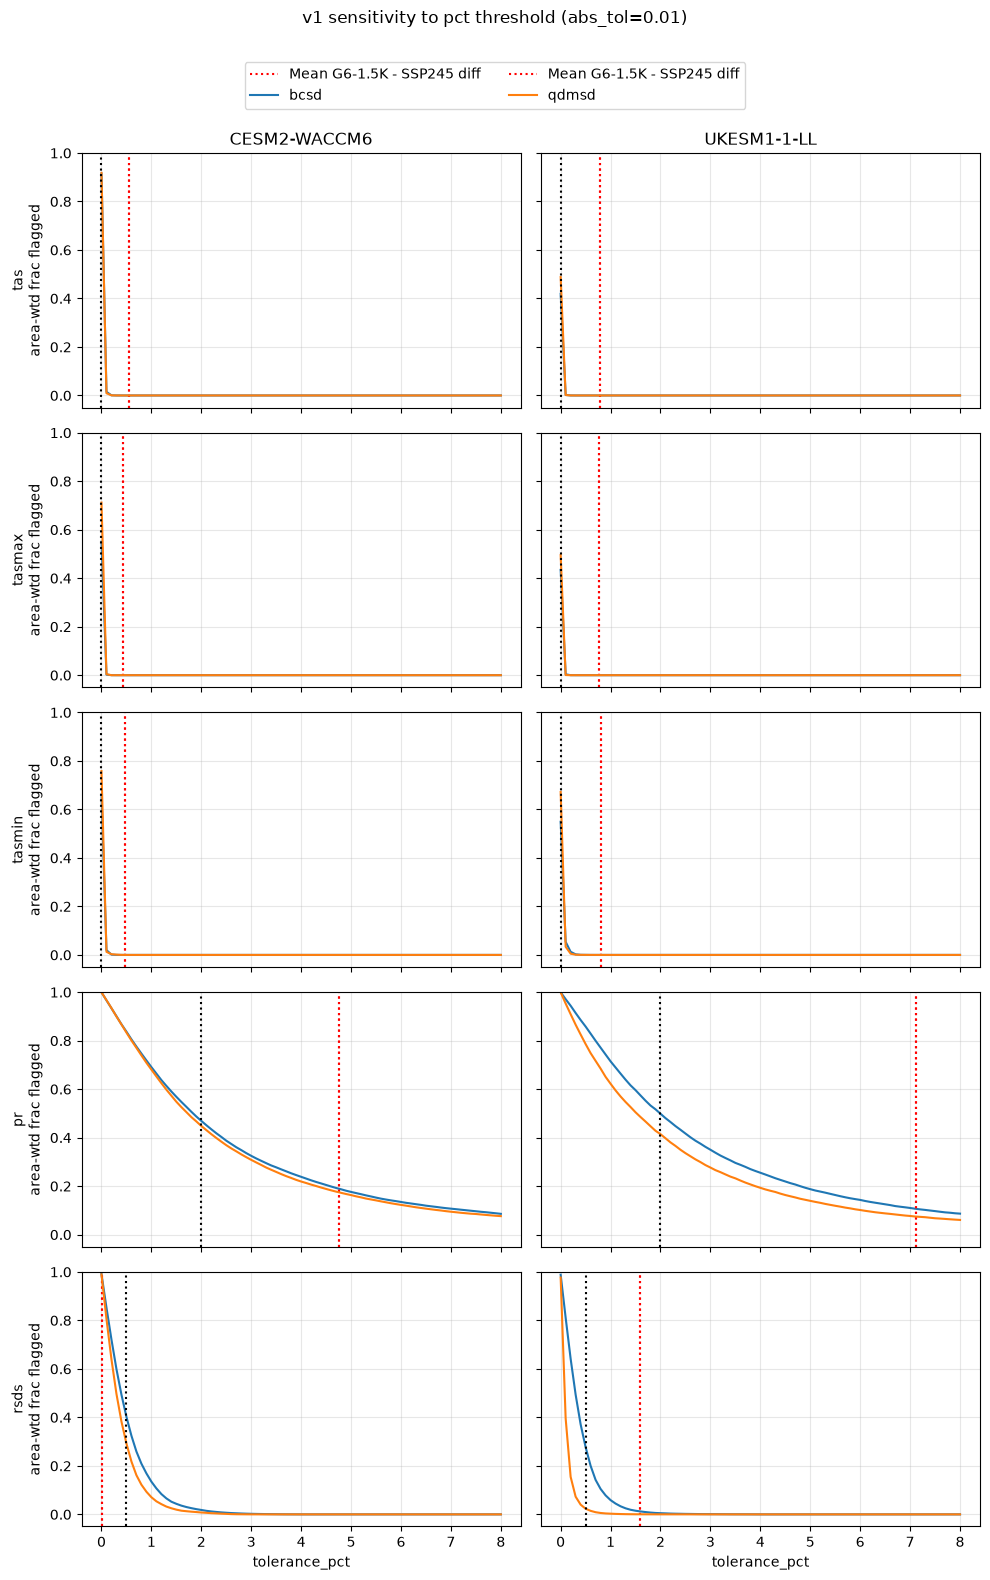

In [10]:
fig, axes = plt.subplots(
    len(VARIABLES),
    len(GCMS),
    figsize=(5 * len(GCMS), 3 * len(VARIABLES)),
    sharex=True,
    sharey="row",
    squeeze=False,
)
for i, variable in enumerate(VARIABLES):
    current_pct_thresh = TREND_VARIABLE_SETTINGS[variable]["pct_tol"]
    for j, gcm in enumerate(GCMS):
        ax = axes[i, j]
        for method in METHODS:
            mean_delta_ref = mean_delta_raw_pct_df.loc[(gcm, variable), method]
            ax.axvline(
                x=np.abs(mean_delta_ref),
                linestyle=":",
                color="r",
                label="Mean G6-1.5K - SSP245 diff",
            )
            key = (gcm, variable, method)
            if key in frac_flagged_v1:
                ax.plot(
                    PCT_THRESHOLDS_V1,
                    frac_flagged_v1[key],  # marker="o", markersize=2,
                    color=METHOD_COLORS[method],
                    label=method,
                )
        if i == 0:
            ax.set_title(gcm)
        if j == 0:
            ax.set_ylabel(f"{variable}\narea-wtd frac flagged")
        if i == len(VARIABLES) - 1:
            ax.set_xlabel("tolerance_pct")
        ax.grid(alpha=0.3)
        # ax.set_xlim([-0.1, 5])
        ax.set_ylim([-0.05, 1])
        ax.axvline(x=current_pct_thresh, linestyle=":", color="k")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(METHODS), bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f"v1 sensitivity to pct threshold (abs_tol={ABS_TOL_SMALL})", y=1.05)
plt.tight_layout()
plt.show()

## Sensitivity: absolute threshold vs. flagged fraction (v1)

Same idea as the pct sweep above, mirrored onto `calculate_distortion_flags`'s *other* condition:
sweeps `tolerance_absolute` with the percent condition disabled (`tolerance_pct=0` -- the
function's own documented way to turn that condition off, rather than a "deliberately small"
stand-in the way the pct sweep uses `ABS_TOL_SMALL` for the absolute side), so this isolates the
absolute condition's effect on its own. The swept range differs by variable
(`ABS_THRESHOLDS_V1_BY_VAR`), since each variable's `distortion_absolute` sits in its own physical
units: `tas`/`tasmax`/`tasmin` sweep 0-3 (K), `pr` sweeps 0-100 (mm/yr), `rsds` sweeps 0-5
(W m⁻²). Recomputes `distortion_absolute`/`distortion_pct` from `deltas` the same way the pct sweep
cell does; the pct sweep above is untouched.

Flagged fraction is area-weighted the same way as the pct sweep above (`area_weights`/`weighted_fraction`), not a naive grid-cell average.

In [11]:
ABS_THRESHOLDS_V1_BY_VAR = {
    "tas": np.arange(0.0, 3.01, 0.03),
    "tasmax": np.arange(0.0, 3.01, 0.03),
    "tasmin": np.arange(0.0, 3.01, 0.03),
    "pr": np.arange(0.0, 100.01, 1.0),
    "rsds": np.arange(0.0, 5.01, 0.05),
}

frac_flagged_v1_abs: dict[tuple[str, str, str], np.ndarray] = {}

for (gcm, variable, method), d in deltas.items():
    scale = TREND_VARIABLE_SETTINGS[variable]["scale"]
    distortion_absolute = (d["delta_ds_coarse"] - d["delta_raw"]) * scale
    distortion_pct = d["delta_ds_coarse_pct"] - d["delta_raw_pct"]
    weights = area_weights(d["delta_raw"]["lat"])

    fracs = []
    for abs_thresh in ABS_THRESHOLDS_V1_BY_VAR[variable]:
        flag = calculate_distortion_flags(
            distortion_absolute=distortion_absolute,
            distortion_pct=distortion_pct,
            tolerance_absolute=abs_thresh,
            tolerance_pct=0,  # disables the pct condition -- see calculate_distortion_flags's docstring
        )
        fracs.append(weighted_fraction(flag, weights))
    frac_flagged_v1_abs[(gcm, variable, method)] = np.array(fracs)

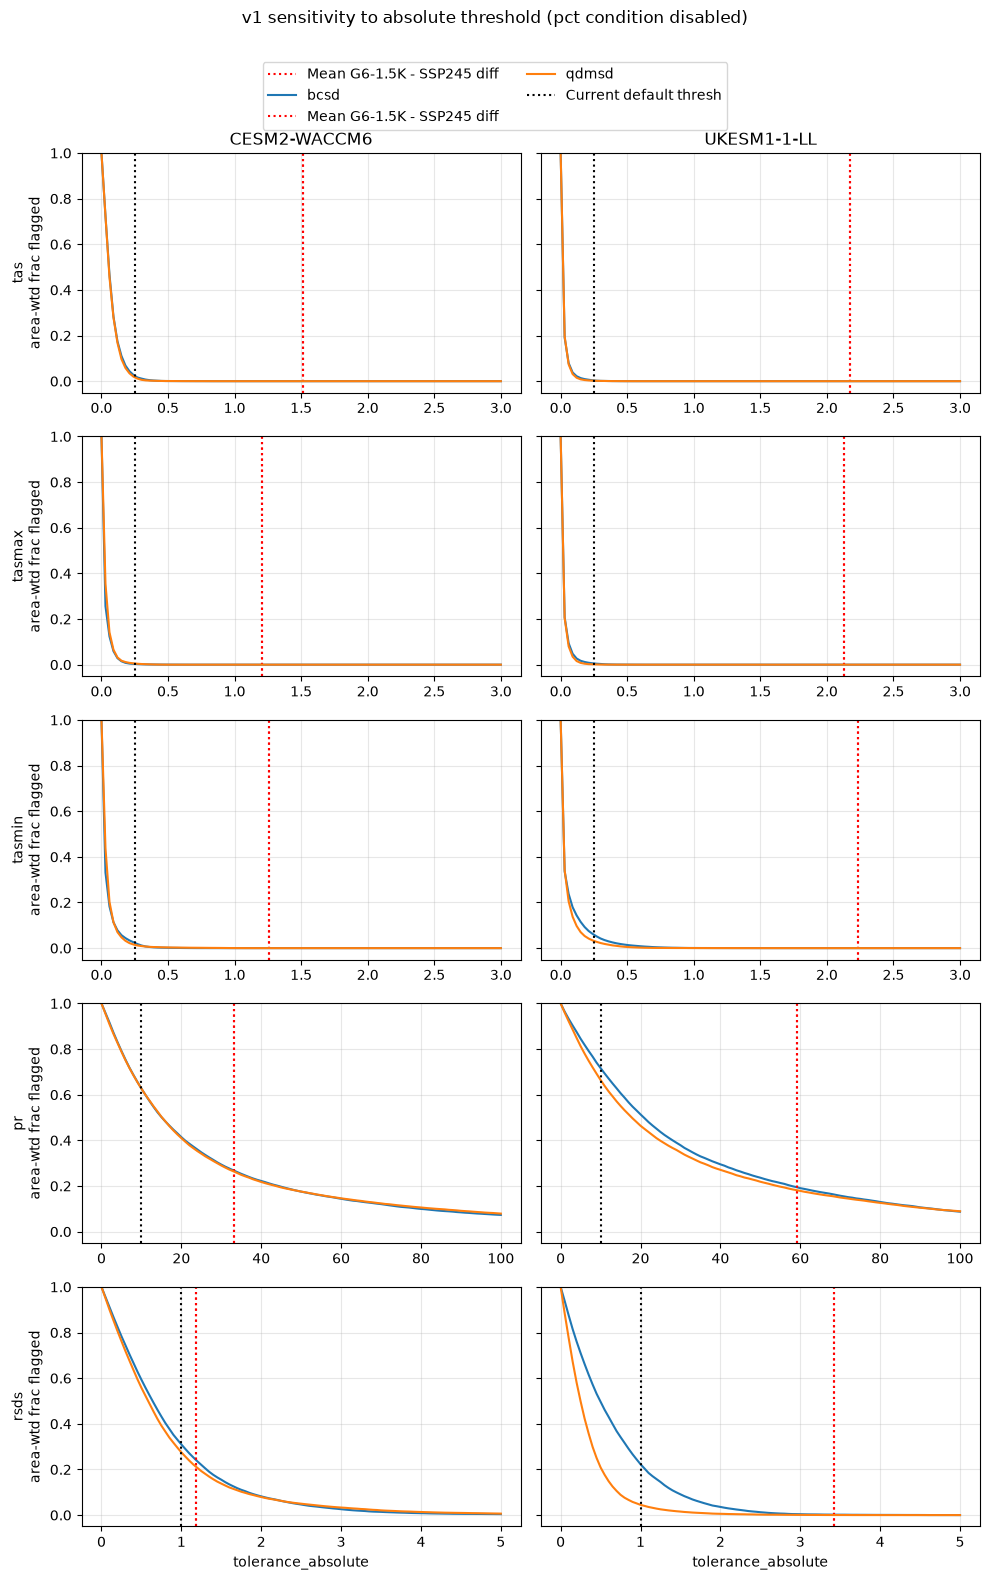

In [12]:
fig, axes = plt.subplots(
    len(VARIABLES),
    len(GCMS),
    figsize=(5 * len(GCMS), 3 * len(VARIABLES)),
    sharex=False,
    sharey="row",
    squeeze=False,
)
for i, variable in enumerate(VARIABLES):
    current_abs_thresh = TREND_VARIABLE_SETTINGS[variable]["abs_tol"]
    for j, gcm in enumerate(GCMS):
        ax = axes[i, j]
        for method in METHODS:
            mean_delta_ref = mean_delta_raw_df.loc[(gcm, variable), method]
            ax.axvline(
                x=np.abs(mean_delta_ref),
                linestyle=":",
                color="r",
                label="Mean G6-1.5K - SSP245 diff",
            )
            key = (gcm, variable, method)
            if key in frac_flagged_v1_abs:
                ax.plot(
                    ABS_THRESHOLDS_V1_BY_VAR[variable],
                    frac_flagged_v1_abs[key],
                    color=METHOD_COLORS[method],
                    label=method,
                )
        if i == 0:
            ax.set_title(gcm)
        if j == 0:
            ax.set_ylabel(f"{variable}\narea-wtd frac flagged")
        if i == len(VARIABLES) - 1:
            ax.set_xlabel("tolerance_absolute")
        ax.grid(alpha=0.3)
        # ax.set_xlim([-0.05, 5])
        ax.set_ylim([-0.05, 1])
        ax.axvline(x=current_abs_thresh, linestyle=":", color="k", label="Current default thresh")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(METHODS), bbox_to_anchor=(0.5, 1.02))
fig.suptitle("v1 sensitivity to absolute threshold (pct condition disabled)", y=1.05)
plt.tight_layout()
plt.show()

## Sensitivity: pct threshold vs. flagged fraction (v2)

Same construction, for `calculate_distortion_flags_v2` -- `PCT_THRESHOLDS_V2` covers a much wider
range than `PCT_THRESHOLDS_V1` because v2's `tolerance_pct` is compared against a
percent-of-a-percent-change signal, not a plain percent change (see the single-variable sandbox's
v2 markdown for why the "same" tolerance value means something different between the two
functions) -- so don't read the v1 and v2 figures as sharing an x-axis, only compare shapes within
each figure.

Flagged fraction is area-weighted the same way as the pct sweep above (`area_weights`/`weighted_fraction`), not a naive grid-cell average.

In [13]:
frac_flagged_v2: dict[tuple[str, str, str], np.ndarray] = {}

for (gcm, variable, method), d in deltas.items():
    scale = TREND_VARIABLE_SETTINGS[variable]["scale"]
    delta_ds_coarse_scaled = d["delta_ds_coarse"] * scale
    delta_raw_scaled = d["delta_raw"] * scale
    weights = area_weights(d["delta_raw"]["lat"])

    fracs = []
    for pct_thresh in PCT_THRESHOLDS_V2:
        flag = calculate_distortion_flags_v2(
            delta_ds_coarse=delta_ds_coarse_scaled,
            delta_raw=delta_raw_scaled,
            delta_ds_coarse_pct=d["delta_ds_coarse_pct"],
            delta_raw_pct=d["delta_raw_pct"],
            tolerance_absolute=ABS_TOL_SMALL,
            tolerance_pct=pct_thresh,
        )
        fracs.append(weighted_fraction(flag, weights))
    frac_flagged_v2[(gcm, variable, method)] = np.array(fracs)

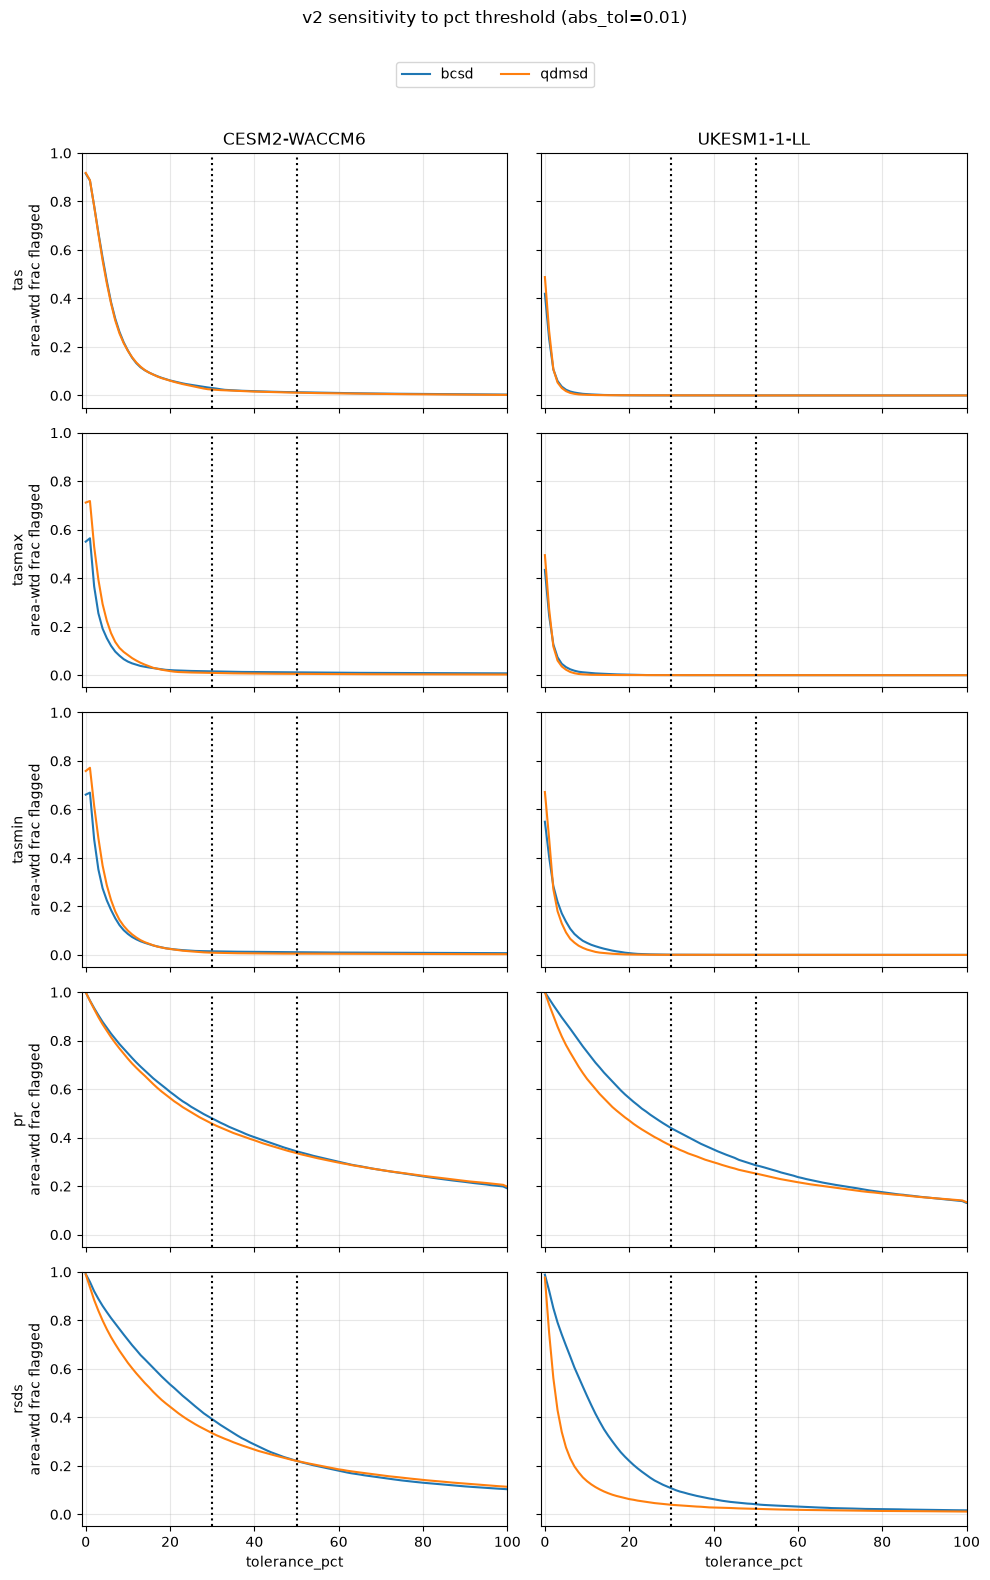

In [14]:
fig, axes = plt.subplots(
    len(VARIABLES),
    len(GCMS),
    figsize=(5 * len(GCMS), 3 * len(VARIABLES)),
    sharex=True,
    sharey="row",
    squeeze=False,
)
for i, variable in enumerate(VARIABLES):
    for j, gcm in enumerate(GCMS):
        ax = axes[i, j]
        for method in METHODS:
            key = (gcm, variable, method)
            if key in frac_flagged_v2:
                ax.plot(
                    PCT_THRESHOLDS_V2,
                    frac_flagged_v2[key],  # marker="o", markersize=2,
                    color=METHOD_COLORS[method],
                    label=method,
                )
        if i == 0:
            ax.set_title(gcm)
        if j == 0:
            ax.set_ylabel(f"{variable}\narea-wtd frac flagged")
        if i == len(VARIABLES) - 1:
            ax.set_xlabel("tolerance_pct")
        ax.grid(alpha=0.3)
        ax.set_xlim([-1, 100])
        ax.set_ylim([-0.05, 1])
        ax.axvline(x=50, linestyle=":", color="k")
        ax.axvline(x=30, linestyle=":", color="k")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(METHODS), bbox_to_anchor=(0.5, 1.02))
fig.suptitle(f"v2 sensitivity to pct threshold (abs_tol={ABS_TOL_SMALL})", y=1.05)
plt.tight_layout()
plt.show()

## Shut down the cluster

In [16]:
cluster.shutdown()

[2026-09-09 22:26:04,310][INFO    ][coiled] Cluster 2028825 deleted successfully.
